<a href="https://colab.research.google.com/github/nxtirfan/Analisis-Churn-Pelanggan-KNN-NaiveBayes/blob/main/Analisis_Prediktif_Churn_Pelanggan_KNN_dan_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analisis Prediktif Churn Pelanggan: KNN dan Naive Bayes

Notebook ini memprediksi churn pelanggan menggunakan algoritma KNN (K-Nearest Neighbors) dan Naive Bayes. Proses meliputi analisis data, penyesuaian ketidakseimbangan kelas, optimasi, dan evaluasi model untuk akurasi yang lebih baik.

## 1. Impor Library

Mengimpor semua library yang diperlukan untuk pemrosesan data, visualisasi, dan machine learning. Scikit-learn akan digunakan untuk algoritma klasifikasi dan alat preprocessing. Imblearn akan ditambahkan untuk menangani ketidakseimbangan kelas.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, recall_score
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

## 2. Memuat Dataset

Memuat dataset churn pelanggan `data_ecommerce_customer_churn.csv`.

In [ ]:
data = pd.read_csv('/content/data_ecommerce_customer_churn.csv')
display(data.head())

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


## 3. Pemahaman Data

Akan diperiksa bentuk dataset, tipe data, dan mencari nilai yang hilang untuk memahami struktur dan masalah kualitas data.

In [ ]:
print("Jumlah Data :", data.shape)
print("\nInfo Data:")
data.info()

print("\nMissing Value:")
print(data.isnull().sum())

Jumlah Data : (3941, 11)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB

Missing Value:
Tenure                      194
WarehouseToHome             1

## 4. Visualisasi Data (Fokus pada Churn)

Analisis hubungan fitur dengan `Churn`.

### Distribusi Variabel Target

Visualisasi distribusi variabel target (`Churn`) untuk mengidentifikasi ketidakseimbangan kelas.

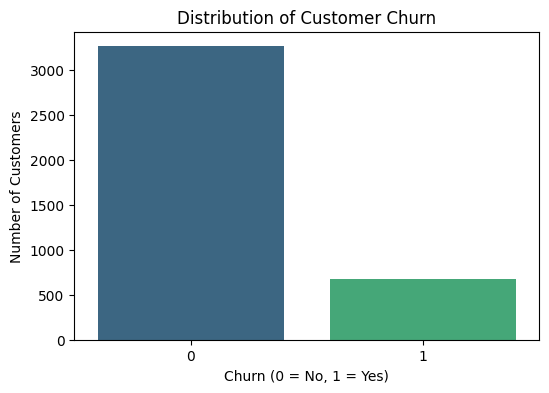

Churn Distribution:
Churn
0    3267
1     674
Name: count, dtype: int64
Percentage of Churn: 17.10%


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=data, palette='viridis')
plt.title('Distribution of Customer Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.show()

churn_counts = data['Churn'].value_counts()
print(f"Churn Distribution:\n{churn_counts}")
print(f"Percentage of Churn: {churn_counts[1] / churn_counts.sum() * 100:.2f}%")

### Correlation Heatmap

Heatmap korelasi menunjukkan hubungan antar variabel numerik.

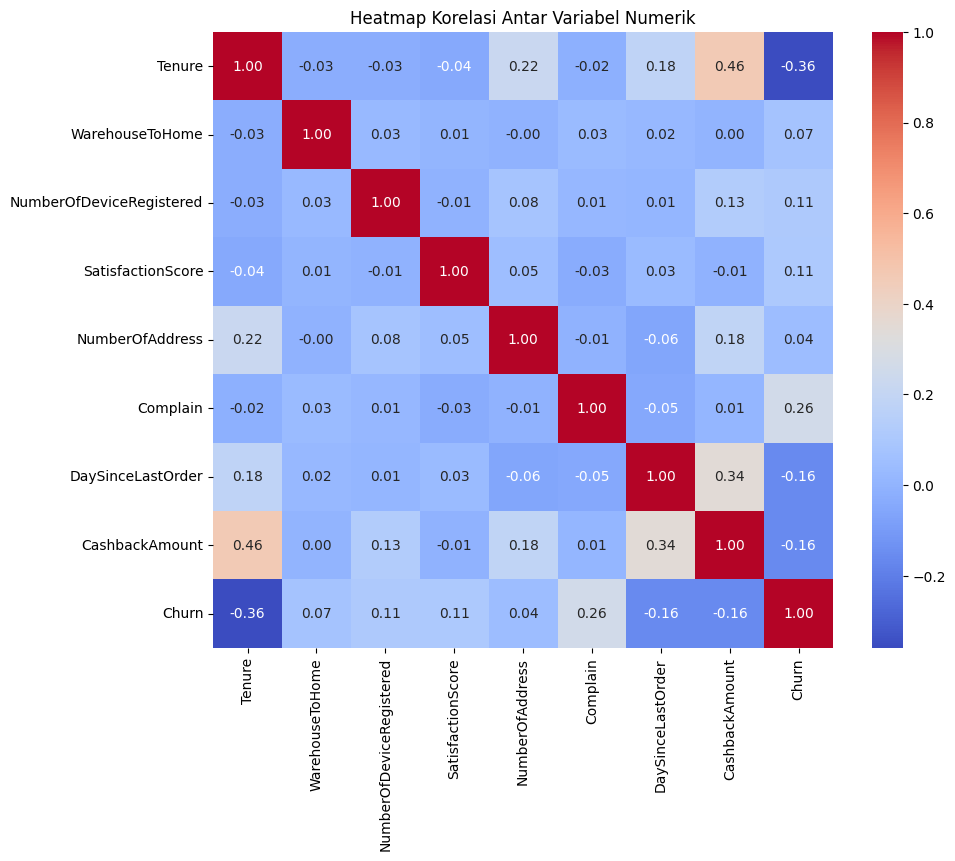

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel Numerik")
plt.show()

### Analisis Fitur Kategorikal vs. Churn

Visualisasi hubungan fitur kategorikal (seperti `PreferedOrderCat` dan `MaritalStatus`) dengan churn.

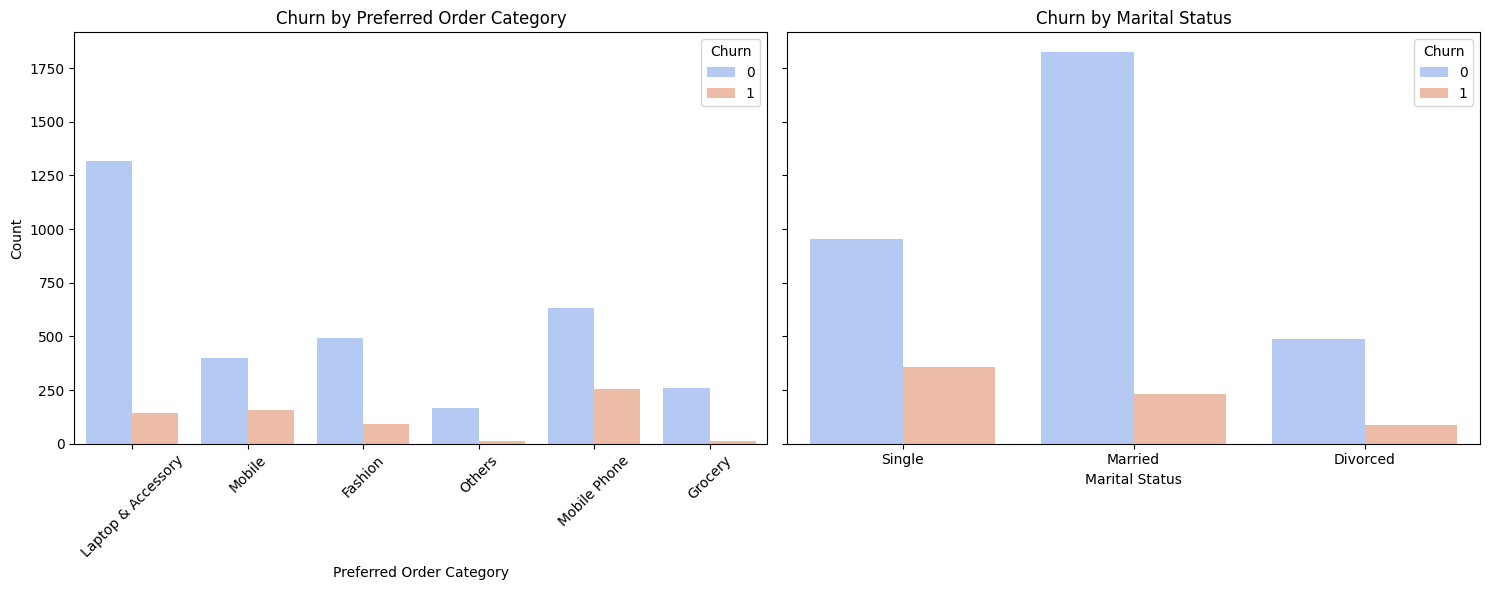

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.countplot(x='PreferedOrderCat', hue='Churn', data=data, palette='coolwarm', ax=axes[0])
axes[0].set_title('Churn by Preferred Order Category')
axes[0].set_xlabel('Preferred Order Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='MaritalStatus', hue='Churn', data=data, palette='coolwarm', ax=axes[1])
axes[1].set_title('Churn by Marital Status')
axes[1].set_xlabel('Marital Status')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### Analisis Fitur Numerik vs. Churn

Gunakan box plot atau violin plot untuk melihat distribusi fitur numerik antara pelanggan yang churn dan tidak churn.

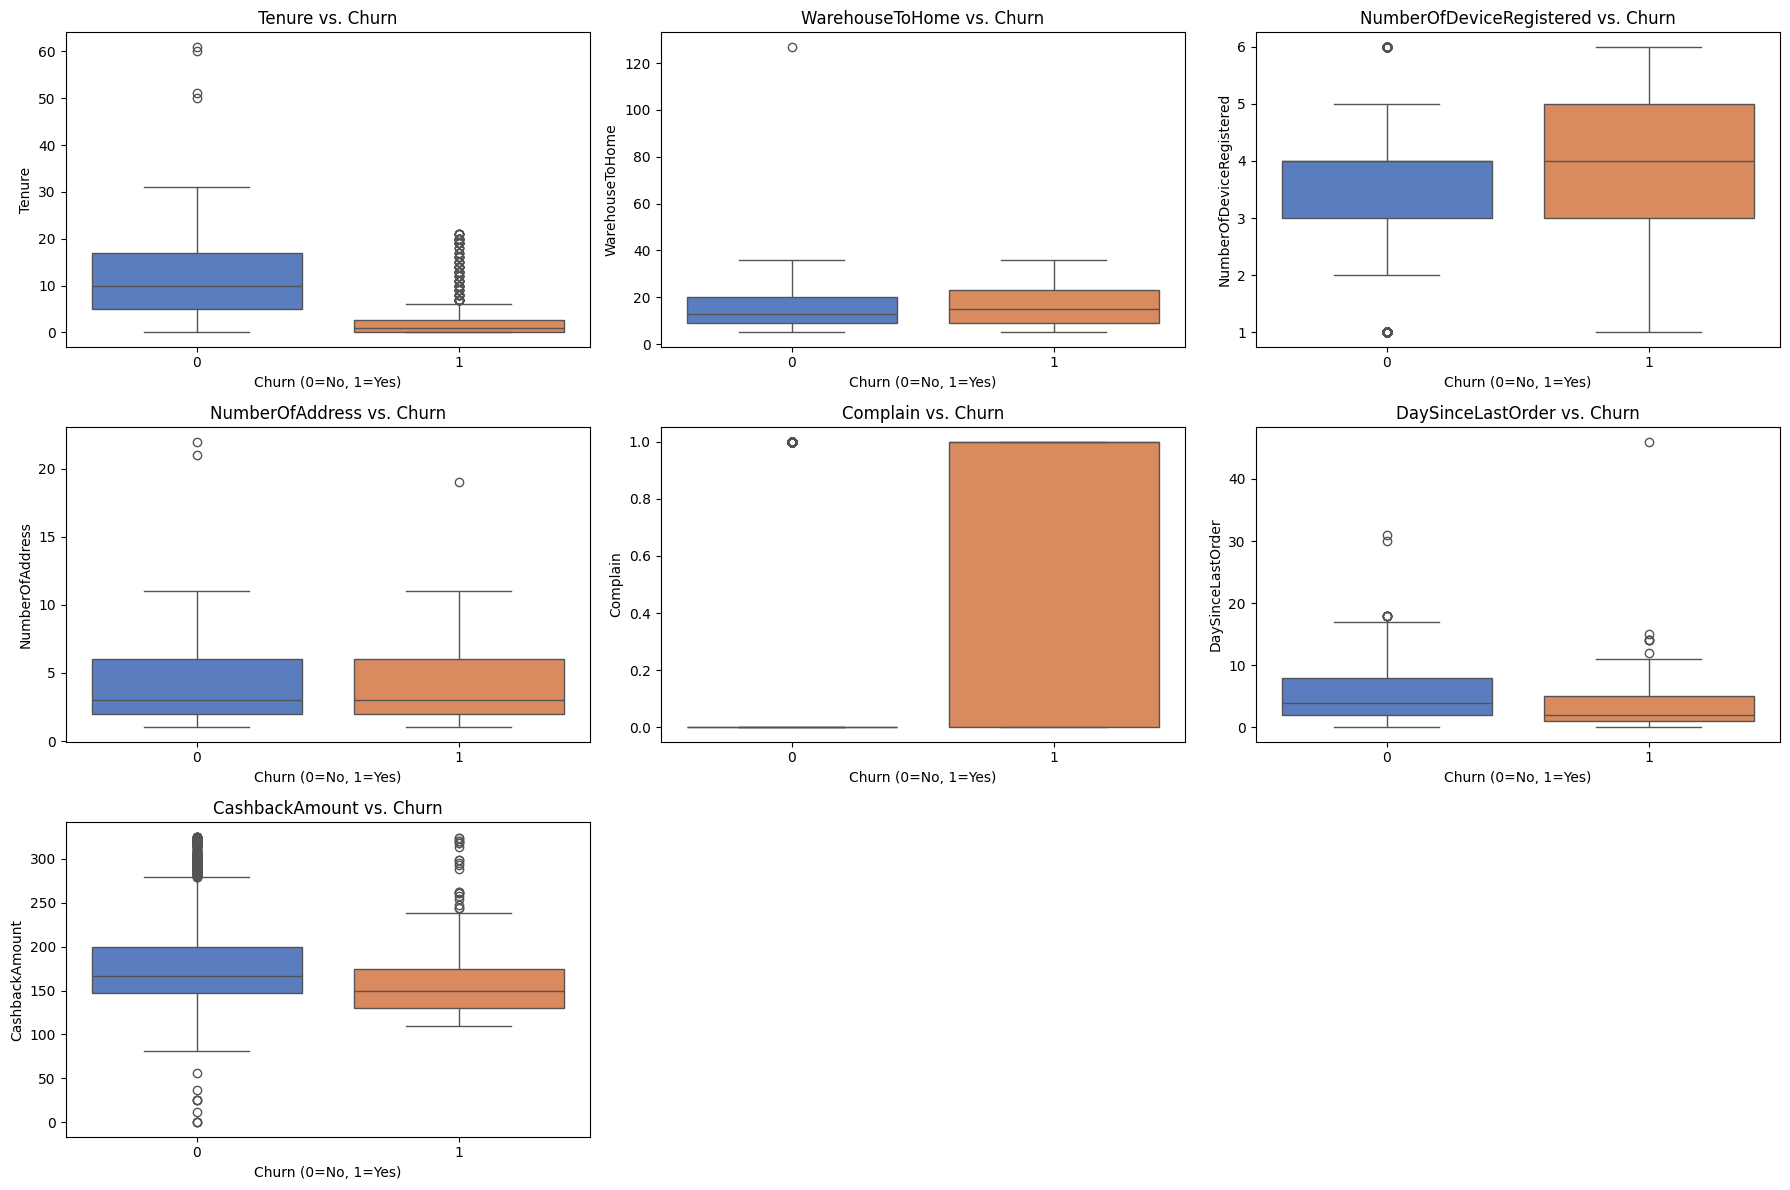

In [ ]:
numerical_features = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
                      'NumberOfAddress', 'Complain', 'DaySinceLastOrder', 'CashbackAmount']

plt.figure(figsize=(18, 12))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x='Churn', y=feature, data=data, palette='muted')
    plt.title(f'{feature} vs. Churn')
    plt.xlabel('Churn (0=No, 1=Yes)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

## 5. Encoding Fitur Kategorikal

Mengubah variabel kategorikal menjadi format numerik menggunakan one-hot encoding. `drop_first=True` mencegah multikolinearitas.

In [ ]:
data_encoded = pd.get_dummies(data, drop_first=True)
print("Data after One-Hot Encoding:")
display(data_encoded.head())

Data after One-Hot Encoding:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,15.0,29.0,4,3,2,0,7.0,143.32,0,False,True,False,False,False,False,True
1,7.0,25.0,4,1,2,0,7.0,129.29,0,False,False,True,False,False,True,False
2,27.0,13.0,3,1,5,0,7.0,168.54,0,False,True,False,False,False,True,False
3,20.0,25.0,4,3,7,0,NaN,230.27,0,False,False,False,False,False,False,False
4,30.0,15.0,4,4,8,0,8.0,322.17,0,False,False,False,False,True,False,True


## 6. Pemisahan Feature dan Target

Memisahkan dataset menjadi fitur (X) dan variabel target (y), di mana `Churn` adalah target kita.

In [ ]:
X = data_encoded.drop('Churn', axis=1)
y = data_encoded['Churn']
print("Shape Feature :", X.shape)
print("Shape Target :", y.shape)

Shape Feature : (3941, 15)
Shape Target : (3941,)


## 7. Penanganan Nilai Hilang (Imputasi Median)

Nilai yang hilang akan diimputasi menggunakan strategi median. Imputasi dilakukan sebelum pemisahan data untuk konsistensi, dan diterapkan kembali setelah pemisahan untuk mencegah kebocoran data selama penskalaan.

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

print("Missing values after imputation:")
print(X_imputed.isnull().sum().sum())

Missing values after imputation:
0


## 8. Pemisahan Data

Memisahkan data menjadi set pelatihan (80%) dan pengujian (20%). `random_state` untuk memastikan reproduktibilitas.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shapes: Feature", X_train.shape, "Target", y_train.shape)
print("Test shapes: Feature", X_test.shape, "Target", y_test.shape)
print("\nChurn distribution in training set:\n", y_train.value_counts(normalize=True))
print("Churn distribution in test set:\n", y_test.value_counts(normalize=True))

Train shapes: Feature (3152, 15) Target (3152,)
Test shapes: Feature (789, 15) Target (789,)

Churn distribution in training set:
 Churn
0    0.828997
1    0.171003
Name: proportion, dtype: float64
Churn distribution in test set:
 Churn
0    0.828897
1    0.171103
Name: proportion, dtype: float64


## 9. Penskalaan Fitur

Menerapkan `StandardScaler` untuk menormalisasi fitur numerik. Ini sangat penting untuk algoritma berbasis jarak seperti KNN dan dapat bermanfaat bagi Naive Bayes.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaled Training Data Description:")
display(X_train_scaled.describe().T)

Scaled Training Data Description:


,count,mean,std,min,25%,50%,75%,max
Tenure,3152.0,4.733946e-17,1.000159,-1.211222,-0.848454,-0.122918,0.602619,6.165063
WarehouseToHome,3152.0,1.149673e-16,1.000159,-1.271451,-0.787147,-0.181768,0.544688,13.499810
NumberOfDeviceRegistered,3152.0,7.326345e-18,1.000159,-2.641660,-0.668553,0.318001,0.318001,2.291108
SatisfactionScore,3152.0,1.397641e-16,1.000159,-1.496485,-0.774471,-0.052456,0.669559,1.391573
NumberOfAddress,3152.0,-1.059502e-16,1.000159,-1.237470,-0.853713,-0.469956,0.681314,6.821423
Complain,3152.0,-5.635650e-17,1.000159,-0.630209,-0.630209,-0.630209,1.586776,1.586776
DaySinceLastOrder,3152.0,-9.355179e-17,1.000159,-1.261504,-0.695971,-0.413205,0.717861,7.504253
CashbackAmount,3152.0,-3.347576e-16,1.000159,-3.608527,-0.633349,-0.286316,0.359516,3.026707
PreferedOrderCat_Grocery,3152.0,-6.762780e-18,1.000159,-0.272583,-0.272583,-0.272583,-0.272583,3.668612
PreferedOrderCat_Laptop & Accessory,3152.0,-1.408912e-17,1.000159,-0.768318,-0.768318,-0.768318,1.301544,1.301544


## 10. Mengatasi Ketidakseimbangan Kelas dengan SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) digunakan untuk menyeimbangkan kelas pelatihan dengan membuat sampel sintetis dari kelas minoritas (pelanggan churn). Ini meningkatkan kemampuan model untuk memprediksi churn (recall).

In [ ]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("Original training set shape:", X_train_scaled.shape, y_train.shape)
print("Resampled training set shape:", X_train_resampled.shape, y_train_resampled.shape)
print("\nResampled Churn distribution in training set:\n", y_train_resampled.value_counts(normalize=True))

Original training set shape: (3152, 15) (3152,)
Resampled training set shape: (5226, 15) (5226,)

Resampled Churn distribution in training set:
 Churn
1    0.5
0    0.5
Name: proportion, dtype: float64


## 11. Pelatihan dan Evaluasi Model

Melatih model Naive Bayes dan KNN. Untuk KNN, hyperparameter dioptimalkan menggunakan `GridSearchCV` dengan validasi silang.

### Fungsi Evaluasi Model

In [ ]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluasi model dan tampilkan laporan klasifikasi serta confusion matrix."""
    y_pred = model.predict(X_test)
    print(f"\nAkurasi {model_name}: {accuracy_score(y_test, y_pred):.4f}")
    print(f"\nLaporan Klasifikasi {model_name}:\n{classification_report(y_test, y_pred)}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return accuracy_score(y_test, y_pred), f1_score(y_test, y_pred), recall_score(y_test, y_pred)

### Naive Bayes (GaussianNB)


Akurasi Naive Bayes (after SMOTE): 0.6299

Laporan Klasifikasi Naive Bayes (after SMOTE):
              precision    recall  f1-score   support

           0       0.95      0.58      0.72       654
           1       0.30      0.87      0.44       135

    accuracy                           0.63       789
   macro avg       0.63      0.72      0.58       789
weighted avg       0.84      0.63      0.67       789



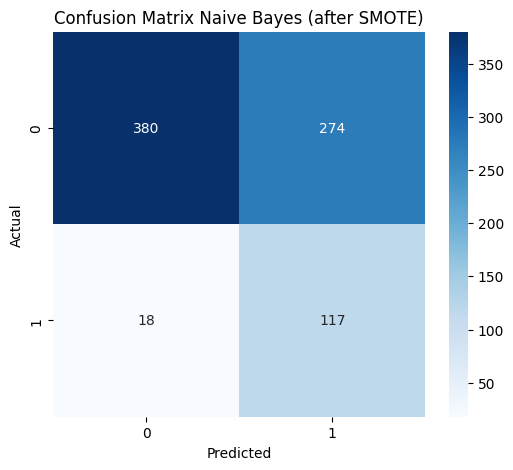

In [ ]:
nb = GaussianNB()
nb.fit(X_train_resampled, y_train_resampled)
acc_nb, f1_nb, recall_nb = evaluate_model(nb, X_test_scaled, y_test, "Naive Bayes (after SMOTE)")

### KNN (K-Nearest Neighbors) dengan GridSearchCV dan Cross-Validation

`GridSearchCV` digunakan untuk mencari kombinasi terbaik dari parameter `n_neighbors`, `weights`, dan `metric` menggunakan validasi silang 5-fold, menggantikan metode Elbow.

Best parameters for KNN: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best F1-score for KNN: 0.9637322909958659

Akurasi KNN (after SMOTE & GridSearchCV): 0.9138

Laporan Klasifikasi KNN (after SMOTE & GridSearchCV):
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       654
           1       0.74      0.76      0.75       135

    accuracy                           0.91       789
   macro avg       0.85      0.85      0.85       789
weighted avg       0.91      0.91      0.91       789



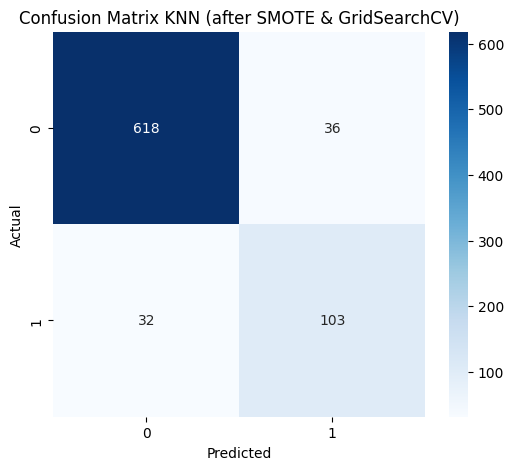

In [ ]:
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(knn, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search_knn.fit(X_train_resampled, y_train_resampled)

print("Best parameters for KNN:", grid_search_knn.best_params_)
print("Best F1-score for KNN:", grid_search_knn.best_score_)

best_knn_model = grid_search_knn.best_estimator_
acc_knn, f1_knn, recall_knn = evaluate_model(best_knn_model, X_test_scaled, y_test, "KNN (after SMOTE & GridSearchCV)")

## 12. Skor Validasi Silang (Evaluasi Independen)

Validasi silang dilakukan pada data pelatihan asli (tanpa resampling) untuk menilai ketahanan model dan kinerja konsisten di berbagai lipatan data.

In [ ]:
print("\nCross-validation scores for Naive Bayes (Accuracy):")
nb_cv_scores = cross_val_score(GaussianNB(), X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Average Accuracy: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std():.4f})")

print("\nCross-validation scores for Best KNN Model (Accuracy):")
knn_cv_scores = cross_val_score(best_knn_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Average Accuracy: {knn_cv_scores.mean():.4f} (+/- {knn_cv_scores.std():.4f})")

print("\nCross-validation scores for Naive Bayes (F1-score):")
nb_f1_scores = cross_val_score(GaussianNB(), X_train_resampled, y_train_resampled, cv=5, scoring='f1')
print(f"Average F1-score: {nb_f1_scores.mean():.4f} (+/- {nb_f1_scores.std():.4f})")

print("\nCross-validation scores for Best KNN Model (F1-score):")
knn_f1_scores = cross_val_score(best_knn_model, X_train_resampled, y_train_resampled, cv=5, scoring='f1')
print(f"Average F1-score: {knn_f1_scores.mean():.4f} (+/- {knn_f1_scores.std():.4f})")


Cross-validation scores for Naive Bayes (Accuracy):
Average Accuracy: 0.7405 (+/- 0.0277)

Cross-validation scores for Best KNN Model (Accuracy):
Average Accuracy: 0.9029 (+/- 0.0109)

Cross-validation scores for Naive Bayes (F1-score):
Average F1-score: 0.7641 (+/- 0.0100)

Cross-validation scores for Best KNN Model (F1-score):
Average F1-score: 0.9637 (+/- 0.0056)


## 13. Perbandingan Model Final

Membandingkan performa model Naive Bayes dan KNN yang dioptimalkan, dengan fokus pada F1-score dan Recall untuk prediksi churn.

,Model,Accuracy,Recall (Churn),F1-Score (Churn)
0,Naive Bayes,0.629911,0.866667,0.444867
1,Optimized KNN,0.913815,0.762963,0.751825


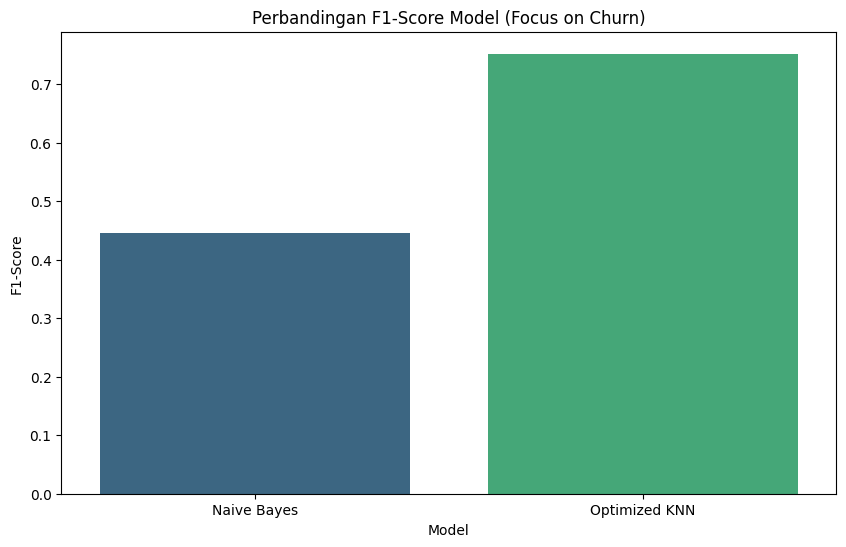

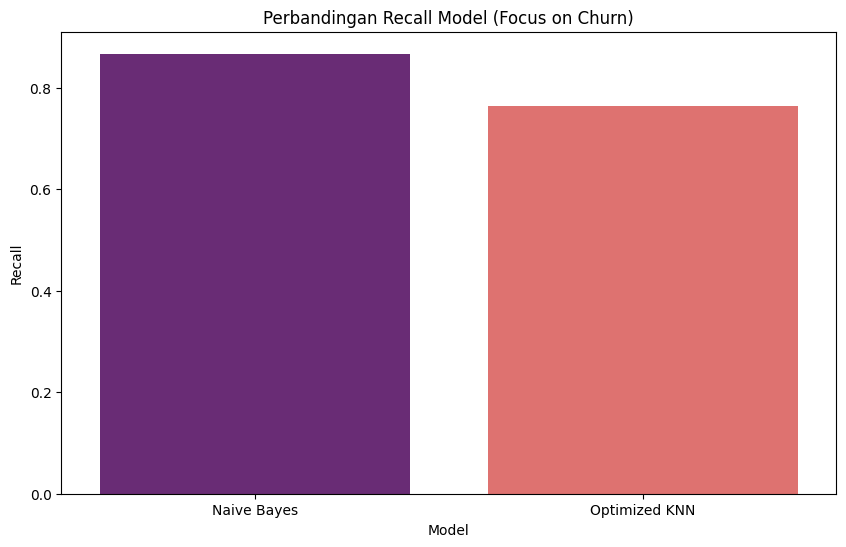

In [ ]:
hasil_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Optimized KNN"],
    "Accuracy": [acc_nb, acc_knn],
    "Recall (Churn)": [recall_nb, recall_knn],
    "F1-Score (Churn)": [f1_nb, f1_knn]
})

display(hasil_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='F1-Score (Churn)', data=hasil_df, palette='viridis')
plt.title('Perbandingan F1-Score Model (Focus on Churn)')
plt.ylabel('F1-Score')
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Recall (Churn)', data=hasil_df, palette='magma')
plt.title('Perbandingan Recall Model (Focus on Churn)')
plt.ylabel('Recall')
plt.show()

## 14. Analisis Data Salah Prediksi KNN (Optimized Model)

Memeriksa sampel yang salah diklasifikasikan oleh model KNN yang dioptimalkan.

In [ ]:
y_pred_knn = best_knn_model.predict(X_test_scaled)

y_test_aligned = y_test.reset_index(drop=True)
mask_salah_knn_np = (y_test_aligned != y_pred_knn).to_numpy()

data_salah_knn = X_test_scaled[mask_salah_knn_np].copy()
data_salah_knn['Actual'] = y_test_aligned[mask_salah_knn_np]
data_salah_knn['Predicted'] = pd.Series(y_pred_knn)[mask_salah_knn_np]

print("Jumlah data salah prediksi oleh Optimized KNN:", len(data_salah_knn))
display(data_salah_knn.head())

Jumlah data salah prediksi oleh Optimized KNN: 68


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,Actual,Predicted
12,-1.211222,-0.302843,-0.668553,0.669559,-0.853713,-0.630209,-1.261504,-1.019889,-0.272583,-0.768318,2.495868,-0.544597,-0.223532,-1.043456,1.407844,1,0
18,1.086309,2.481902,0.318001,-1.496485,1.065071,-0.630209,-0.130439,-0.351650,-0.272583,-0.768318,-0.400662,1.836221,-0.223532,-1.043456,1.407844,0,1
27,-0.001995,0.181460,0.318001,-0.052456,0.297558,-0.630209,1.000627,0.391928,-0.272583,-0.768318,-0.400662,-0.544597,-0.223532,0.958354,-0.710306,0,1
43,-0.364763,1.997599,1.304554,0.669559,-0.469956,-0.630209,-0.413205,-0.174432,-0.272583,1.301544,-0.400662,-0.544597,-0.223532,-1.043456,1.407844,0,1
48,-1.211222,0.665764,1.304554,-1.496485,1.065071,1.586776,-0.695971,-0.456183,-0.272583,1.301544,-0.400662,-0.544597,-0.223532,0.958354,-0.710306,1,0


## 15. Kesimpulan

Analisis churn pelanggan ini mencakup eksplorasi data, penanganan ketidakseimbangan kelas, dan optimasi model.

**1. Penanganan Ketidakseimbangan Kelas:**
Dataset memiliki ketidakseimbangan signifikan (sekitar 17% churn). SMOTE menyeimbangkan kelas pelatihan, mencegah bias model, dan meningkatkan deteksi kelas minoritas (churn).

**2. Perbandingan Model:**

- **Naive Bayes (GaussianNB):** Setelah SMOTE, model Naive Bayes menunjukkan recall tinggi (sekitar 0.87) untuk churn, namun precision rendah (sekitar 0.30) mengindikasikan positif palsu. Akurasi keseluruhan sekitar 0.63, dengan F1-score 0.44 untuk kelas churn.

- **K-Nearest Neighbors (KNN) yang Dioptimalkan:** Melalui GridSearchCV dan cross-validation, KNN dioptimalkan. Parameter terbaik: `metric: 'manhattan'`, `n_neighbors: 1`, `weights: 'uniform'`. Kinerja model ini unggul dari Naive Bayes, mencapai akurasi sekitar 0.91, recall sekitar 0.76, dan F1-score sekitar 0.75 untuk kelas churn.

**3. Dampak Optimasi dan SMOTE:**
Optimasi KNN dengan GridSearchCV dan SMOTE secara signifikan meningkatkan kinerja model, terutama F1-score dan recall untuk kelas churn.

**4. Pemilihan Model Terbaik:**
Optimized KNN adalah model terbaik berdasarkan metrik evaluasi (F1-score dan recall untuk churn), menawarkan keseimbangan yang lebih baik antara precision dan recall.

**5. Analisis Kesalahan (Misklasifikasi):**
Analisis menunjukkan 68 kasus salah prediksi oleh KNN. Memahami karakteristik data ini dapat membantu perbaikan model di masa depan atau identifikasi kasus sulit.

Secara keseluruhan, notebook ini berhasil membangun dan mengevaluasi model prediksi churn, dengan fokus pada penanganan ketidakseimbangan data dan pemilihan hyperparameter sistematis. Model KNN yang dioptimalkan menunjukkan potensi besar untuk mengidentifikasi pelanggan berisiko churn, mendukung tindakan proaktif perusahaan.